In [119]:
!pip install boto3 s3fs

In [123]:
import pandas as pd

df = pd.read_csv(
    "s3://003019081-b-bucket/processed/banjir_jakarta_2023_cleaned (1).csv",
    sep=";"
)

df

,periode_data,bulan,wilayah,kecamatan,kelurahan,jumlah_rw_terdampak,jumlah_kk_terdampak,jumlah_jiwa_terdampak,jumlah_kejadian,jumlah_korban_meninggal,jumlah_korban_luka,jumlah_pengungsi,jumlah_tempat_pengungsian,nilai_kerugian,rata_rata_ketinggian_air_num
0,202303,2,JAKARTA SELATAN,KEBAYORAN LAMA,GROGOL SELATAN,2,0,0,1,0,0,0,0,0,50.0
1,202303,2,JAKARTA SELATAN,KEBAYORAN LAMA,KEBAYORAN LAMA SELATAN,1,0,0,1,0,0,0,0,0,20.0
2,202303,2,JAKARTA SELATAN,MAMPANG PRAPATAN,PELA MAMPANG,1,0,0,1,0,0,0,0,0,32.5
3,202303,2,JAKARTA SELATAN,MAMPANG PRAPATAN,TEGAL PARANG,1,0,0,1,0,0,0,0,0,40.0
4,202303,2,JAKARTA SELATAN,MAMPANG PRAPATAN,KUNINGAN BARAT,3,0,0,1,0,0,0,0,0,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,202312,12,JAKARTA SELATAN,PASAR MINGGU,CILANDAK TIMUR,1,314,975,2,0,0,60,1,0,57.5
190,202312,12,JAKARTA TIMUR,JATINEGARA,BIDARA CINA,2,2,10,1,0,0,0,0,0,75.0
191,202312,12,JAKARTA TIMUR,JATINEGARA,KAMPUNG MELAYU,4,0,0,2,0,0,0,0,0,90.0
192,202312,12,JAKARTA TIMUR,KRAMAT JATI,CAWANG,5,0,0,1,0,0,0,0,0,120.0


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   periode_data                  194 non-null    int64  
 1   bulan                         194 non-null    int64  
 2   wilayah                       194 non-null    object 
 3   kecamatan                     194 non-null    object 
 4   kelurahan                     194 non-null    object 
 5   jumlah_rw_terdampak           194 non-null    int64  
 6   jumlah_kk_terdampak           194 non-null    int64  
 7   jumlah_jiwa_terdampak         194 non-null    int64  
 8   jumlah_kejadian               194 non-null    int64  
 9   jumlah_korban_meninggal       194 non-null    int64  
 10  jumlah_korban_luka            194 non-null    int64  
 11  jumlah_pengungsi              194 non-null    int64  
 12  jumlah_tempat_pengungsian     194 non-null    int64  
 13  nilai

In [125]:
df.columns

Index(['periode_data', 'bulan', 'wilayah', 'kecamatan', 'kelurahan',
       'jumlah_rw_terdampak', 'jumlah_kk_terdampak', 'jumlah_jiwa_terdampak',
       'jumlah_kejadian', 'jumlah_korban_meninggal', 'jumlah_korban_luka',
       'jumlah_pengungsi', 'jumlah_tempat_pengungsian', 'nilai_kerugian',
       'rata_rata_ketinggian_air_num'],
      dtype='object')

In [126]:
df.isnull().sum()

periode_data                    0
bulan                           0
wilayah                         0
kecamatan                       0
kelurahan                       0
jumlah_rw_terdampak             0
jumlah_kk_terdampak             0
jumlah_jiwa_terdampak           0
jumlah_kejadian                 0
jumlah_korban_meninggal         0
jumlah_korban_luka              0
jumlah_pengungsi                0
jumlah_tempat_pengungsian       0
nilai_kerugian                  0
rata_rata_ketinggian_air_num    0
dtype: int64

In [127]:
banjir_per_bulan = df.groupby('bulan')['jumlah_kejadian'].sum().reset_index()
banjir_per_bulan


,bulan,jumlah_kejadian
0,1,19
1,2,50
2,3,24
3,4,6
4,5,25
5,6,7
6,7,12
7,8,0
8,9,0
9,11,49


In [128]:
# =========================
# ANALISIS 2: WILAYAH RAWAN
# =========================
banjir_per_wilayah = df.groupby('wilayah')['jumlah_kejadian'].sum().reset_index()
banjir_per_wilayah

,wilayah,jumlah_kejadian
0,JAKARTA BARAT,44
1,JAKARTA PUSAT,1
2,JAKARTA SELATAN,90
3,JAKARTA TIMUR,66
4,JAKARTA UTARA,10
5,KEPULAUAN SERIBU,0
6,TIDAK ADA BANJIR,0


In [129]:
df[[
    'jumlah_kejadian',
    'jumlah_jiwa_terdampak',
    'jumlah_pengungsi',
    'rata_rata_ketinggian_air_num'
]].describe()

,jumlah_kejadian,jumlah_jiwa_terdampak,jumlah_pengungsi,rata_rata_ketinggian_air_num
count,194.000000,194.000000,194.000000,194.000000
mean,1.087629,15.757732,0.381443,48.208763
std,0.710799,102.753632,4.321157,30.642625
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,30.000000
50%,1.000000,0.000000,0.000000,42.500000
75%,1.000000,0.000000,0.000000,60.000000
max,5.000000,975.000000,60.000000,180.000000


In [130]:
# =========================
# ANALISIS 3: KEPARAHAN
# =========================
df['tingkat_keparahan'] = df['rata_rata_ketinggian_air_num'].apply(
    lambda x: 'Rendah' if x < 50 else ('Sedang' if x < 100 else 'Tinggi')
)

keparahan_summary = df.groupby('tingkat_keparahan')['jumlah_kejadian'].count().reset_index()
keparahan_summary

,tingkat_keparahan,jumlah_kejadian
0,Rendah,115
1,Sedang,64
2,Tinggi,15


In [131]:
# =========================
# ANALISIS 4: HUBUNGAN
# =========================
korelasi = df[['rata_rata_ketinggian_air_num', 'jumlah_jiwa_terdampak']].corr()
korelasi

,rata_rata_ketinggian_air_num,jumlah_jiwa_terdampak
rata_rata_ketinggian_air_num,1.000000,-0.040139
jumlah_jiwa_terdampak,-0.040139,1.000000


In [132]:
# =========================
# ANALISIS 5: INDIKASI PERIODE RAWAN
# =========================
threshold = banjir_per_bulan['jumlah_kejadian'].mean()

banjir_per_bulan['status'] = banjir_per_bulan['jumlah_kejadian'].apply(
    lambda x: 'Rawan' if x > threshold else 'Normal'
)
banjir_per_bulan

,bulan,jumlah_kejadian,status
0,1,19,Normal
1,2,50,Rawan
2,3,24,Rawan
3,4,6,Normal
4,5,25,Rawan
5,6,7,Normal
6,7,12,Normal
7,8,0,Normal
8,9,0,Normal
9,11,49,Rawan


VISUALISASI

In [151]:
import boto3

s3 = boto3.client('s3')

from io import StringIO

csv_buffer = StringIO()
df.to_csv(csv_buffer, index=False)

s3.put_object(
    Bucket='003019081-b-bucket',
    Key='processed/data_banjir_bersih.csv',
    Body=csv_buffer.getvalue()
)


{'ResponseMetadata': {'RequestId': '24ZR37P7RCQQRSS9',
  'HostId': 'ySrPkY1atVTFXsvratgAwyphEFbGOqihqCckxHaKsVkhKHbuZBhQuTbj+qH5+dkPvAh8OeCeg3jlUHc/I3G8CoGF10rLoBEu',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'ySrPkY1atVTFXsvratgAwyphEFbGOqihqCckxHaKsVkhKHbuZBhQuTbj+qH5+dkPvAh8OeCeg3jlUHc/I3G8CoGF10rLoBEu',
   'x-amz-request-id': '24ZR37P7RCQQRSS9',
   'date': 'Tue, 14 Apr 2026 10:24:54 GMT',
   'x-amz-version-id': 'RIK6hG4A2RrUNoRvghCdN23Zxg6uSv9e',
   'x-amz-server-side-encryption': 'AES256',
   'etag': '"ab780e388d15939433b37f8bfe39d4c9"',
   'x-amz-checksum-crc32': 'Mo4E3Q==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'ETag': '"ab780e388d15939433b37f8bfe39d4c9"',
 'ChecksumCRC32': 'Mo4E3Q==',
 'ChecksumType': 'FULL_OBJECT',
 'ServerSideEncryption': 'AES256',
 'VersionId': 'RIK6hG4A2RrUNoRvghCdN23Zxg6uSv9e'}

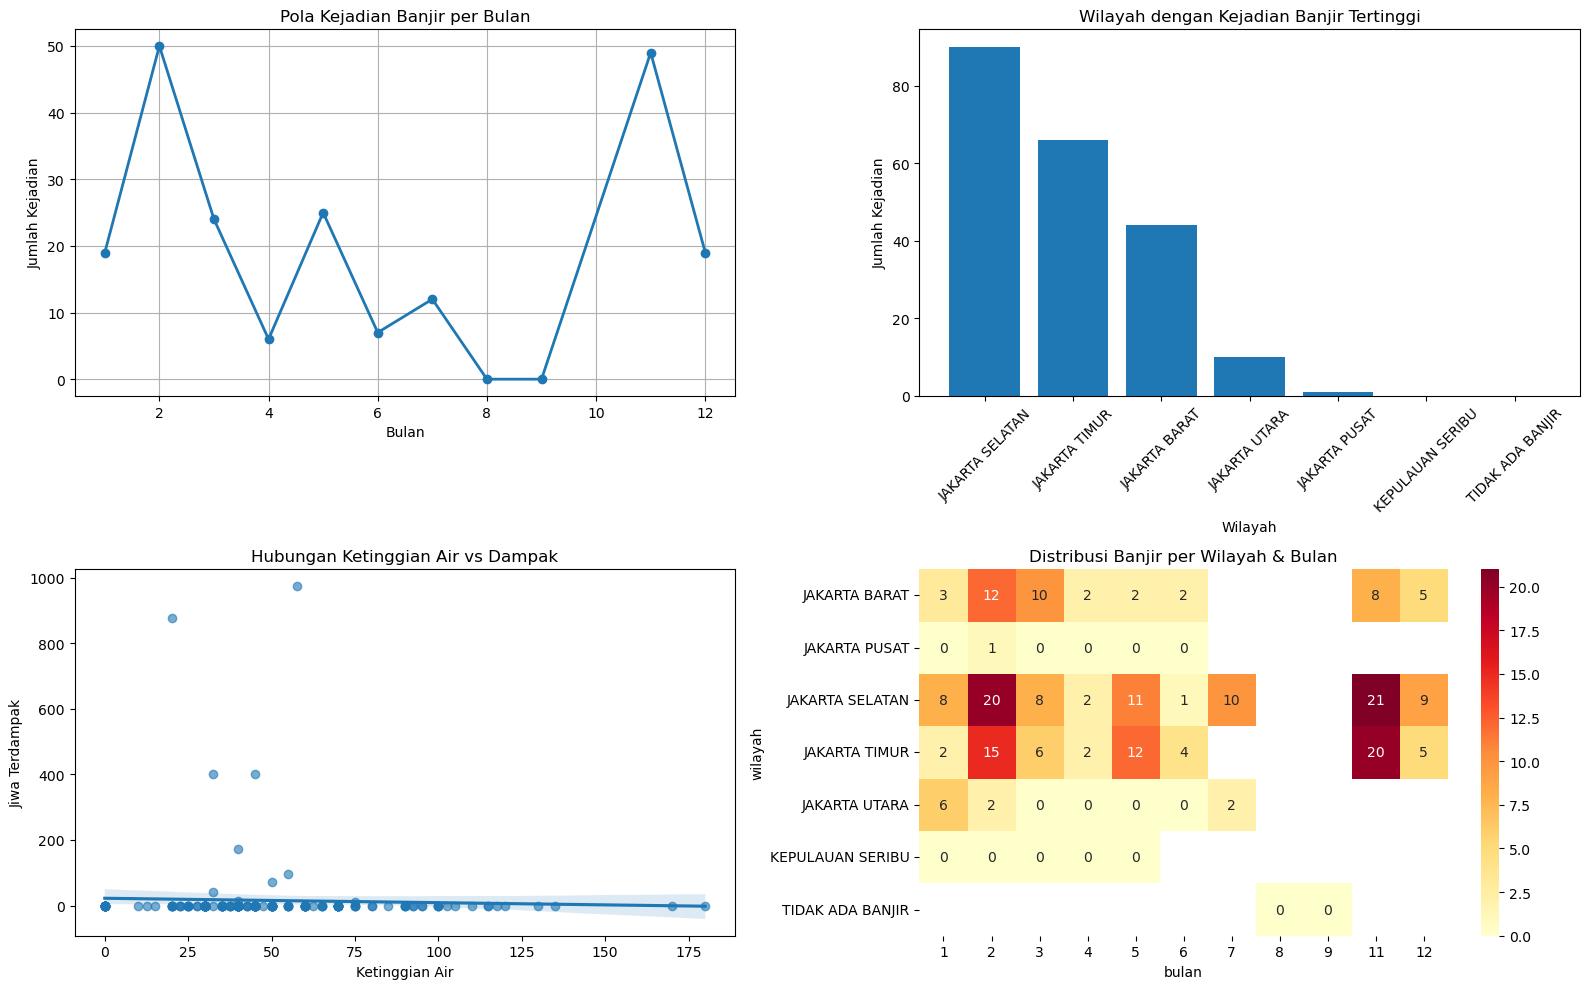

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,10))

# =========================
# 1. POLA BULANAN (LINE)
# =========================
plt.subplot(2,2,1)

banjir_per_bulan = df.groupby('bulan')['jumlah_kejadian'].sum().reset_index()

plt.plot(
    banjir_per_bulan['bulan'],
    banjir_per_bulan['jumlah_kejadian'],
    marker='o',
    linewidth=2
)
plt.title('Pola Kejadian Banjir per Bulan')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Kejadian')
plt.grid()

# =========================
# 2. WILAYAH RAWAN 
# =========================
plt.subplot(2,2,2)

banjir_per_wilayah = df.groupby('wilayah')['jumlah_kejadian'].sum().reset_index()
banjir_per_wilayah = banjir_per_wilayah.sort_values(by='jumlah_kejadian', ascending=False)

plt.bar(
    banjir_per_wilayah['wilayah'],
    banjir_per_wilayah['jumlah_kejadian']
)

plt.xticks(rotation=45)
plt.title('Wilayah dengan Kejadian Banjir Tertinggi')
plt.xlabel('Wilayah')
plt.ylabel('Jumlah Kejadian')

# =========================
# 3. HUBUNGAN VARIABEL (SCATTER + TREND)
# =========================
plt.subplot(2,2,3)

sns.regplot(
    data=df,
    x='rata_rata_ketinggian_air_num',
    y='jumlah_jiwa_terdampak',
    scatter_kws={'alpha':0.6}
)

plt.title('Hubungan Ketinggian Air vs Dampak')
plt.xlabel('Ketinggian Air')
plt.ylabel('Jiwa Terdampak')

# =========================
# 4. HEATMAP
# =========================
plt.subplot(2,2,4)

pivot = df.pivot_table(
    values='jumlah_kejadian',
    index='wilayah',
    columns='bulan',
    aggfunc='sum'
)

sns.heatmap(pivot, annot=True, cmap='YlOrRd')
plt.title('Distribusi Banjir per Wilayah & Bulan')

# =========================
plt.tight_layout()
plt.show()

In [143]:
!pip install folium

In [144]:
import pandas as pd
import folium
import json

In [145]:
with open('kecamatan.geojson') as f:
    geo_data = json.load(f)

In [146]:
geo_data['features'][0]['properties']

{'name': 'GAMBIR'}

In [147]:
# buat dict mapping
df_dict = dict(zip(banjir_kecamatan['kecamatan'], banjir_kecamatan['jumlah_kejadian']))

# inject ke geojson
for feature in geo_data['features']:
    kec = feature['properties']['name']
    feature['properties']['jumlah_banjir'] = df_dict.get(kec, 0)

In [148]:
folium.GeoJson(
    geo_data,
    style_function=lambda x: {
        'fillColor': 'transparent',
        'color': 'black',
        'weight': 1
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['name', 'jumlah_banjir'],
        aliases=['Kecamatan:', 'Jumlah Banjir:'],
        localize=True
    )
).add_to(map_jakarta)

map_jakarta